<h1>Homework 1</h1>

<p>We look at the data visualization of Python. We first graph a box plot of a dataset. Then we plot the relationship between the coffee price and coffee consumption</p>
<p>The variables are:</p>
<p><b>Coffee Price:</b> dollar per pound<br />
<b>Sugar Price:</b> dollar per pound<br />
<b>Tea Price:</b> dollar per pound<br />
<b>Family Income:</b> Annual family salary in U.S. dollars<br />
<b>Coffee consumption:</b> cups annually per person<br />
<b>U.S. Population:</b> Number of people</p>


In [1]:
# Import libraries
import pandas as pd

# Step 1: Create the dataset
data = {
    "Year": [
        1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,
        2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,
        2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,
        2020,2021,2022,2023
    ],
    "Coffee_consumption": [
        267.22,270.57,309.06,301.31,214.79,227.25,258.69,197.95,256.66,292.83,
        312.61,362.14,369.48,378.24,358.46,335.95,328.86,331.54,313.35,320.28,
        293.27,180.05,269.84,340.41,266.42,352.33,346.80,384.27,417.02,437.73,
        431.12,378.27,315.29,376.35
    ],
    "Coffee_price": [
        0.91,0.86,0.65,0.69,1.45,1.46,1.16,1.79,1.29,1.04,
        0.90,0.56,0.54,0.62,0.77,1.08,1.08,1.18,1.33,1.26,
        1.64,2.53,1.75,1.26,1.78,1.33,1.37,1.33,1.14,1.02,
        1.11,1.69,2.14,1.70
    ],
    "Sugar_price": [
        0.13,0.09,0.09,0.10,0.12,0.12,0.11,0.11,0.09,0.06,
        0.08,0.08,0.06,0.07,0.07,0.10,0.15,0.10,0.12,0.18,
        0.22,0.27,0.22,0.17,0.16,0.13,0.18,0.16,0.12,0.12,
        0.13,0.18,0.19,0.24
    ],
    "Tea_price": [
        0.92,0.84,0.91,0.84,0.83,0.75,0.81,1.08,1.08,1.06,
        1.13,0.90,0.81,0.88,0.90,0.98,1.10,0.96,1.23,1.43,
        1.44,1.57,1.59,1.21,1.08,1.55,1.31,1.65,1.36,1.22,
        1.15,1.21,1.26,1.32
    ],
    "Annual_income": [
        42650,43240,44220,47220,49340,51350,53680,56900,59590,62570,
        65770,66860,66970,68560,70390,73300,77320,78850,79630,78540,
        78180,81010,82840,87670,88770,92670,97360,103200,106000,116700,
        115300,121800,126500,135700
    ]
}

# Create a Pandas dataframe
df = pd.DataFrame(data)

# Display first few rows
print(df.head())

   Year  Coffee_consumption  Coffee_price  Sugar_price  Tea_price  \
0  1990              267.22          0.91         0.13       0.92   
1  1991              270.57          0.86         0.09       0.84   
2  1992              309.06          0.65         0.09       0.91   
3  1993              301.31          0.69         0.10       0.84   
4  1994              214.79          1.45         0.12       0.83   

   Annual_income  
0          42650  
1          43240  
2          44220  
3          47220  
4          49340  


<p>This plot summarizes the distributions of coffee
consumption and prices. The orange line inside each box represents the median, while the
top and bottom of the box correspond to the 75th and 25th percentiles, respectively. The
distance between these two percentiles is known as the interquartile range (IQR) and
measures the spread of the middle 50 percent of the data.</p>

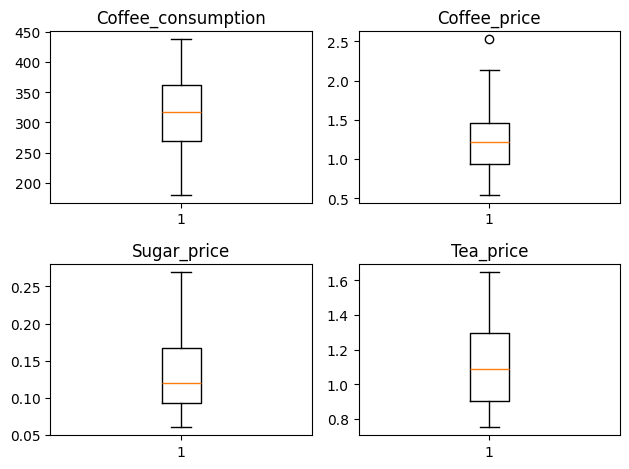

In [2]:
# Import library
import matplotlib.pyplot as plt

# Remove Year variable
stats = df.drop( ["Year","Annual_income"], axis=1)

# Create subplots (one for each variable)
fig, axes = plt.subplots(nrows=2, ncols=2)

# Flatten axes for easy looping
axes = axes.flatten()

# Loop through variables and plot
for i, col in enumerate(stats.columns):
    axes[i].boxplot(stats[col])
    axes[i].set_title(col)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

<p>Several important insights can be drawn from the next figure:</p>
<p>- The negative slope supports standard economic theory, the Law of Demand.<br />
- The dispersion of points indicates that factors other than price—such as income and
substitute goods—also influence consumption.<br />
- The presence of variability around the line suggests that a multivariate regression
model is necessary to better explain coffee demand.<p>

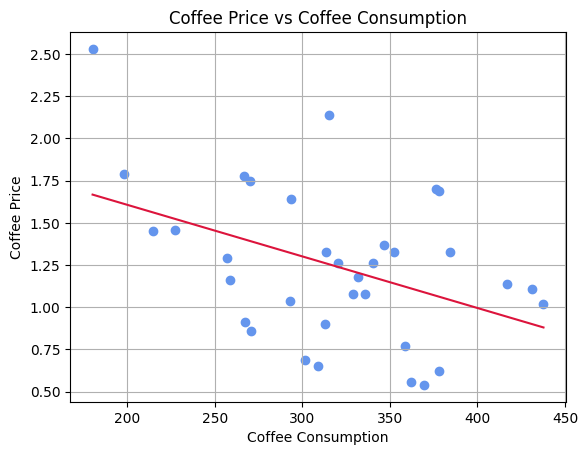

In [3]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np

# Define variables (switched axes)
x = df["Coffee_consumption"]
y = df["Coffee_price"]

# Create scatter plot
plt.figure()
plt.scatter(x, y, color="cornflowerblue")

# Add regression line
m, b = np.polyfit(x, y, 1)

# Sort for smooth line
sorted_idx = np.argsort(x)
x_sorted = x.iloc[sorted_idx]
y_pred = m * x_sorted + b

plt.plot(x_sorted, y_pred, color="crimson")

# Labels and title
plt.xlabel("Coffee Consumption")
plt.ylabel("Coffee Price")
plt.title("Coffee Price vs Coffee Consumption")

# Grid
plt.grid()

# Show plot
plt.show()

<p>The next plot shows the closing index for Hang Seng, the Hong Kong Stock Market. We also plot the 200 day and 50 day moving average. We also indicate a bull market by the green shading, and a bear market by the red shading.</p>

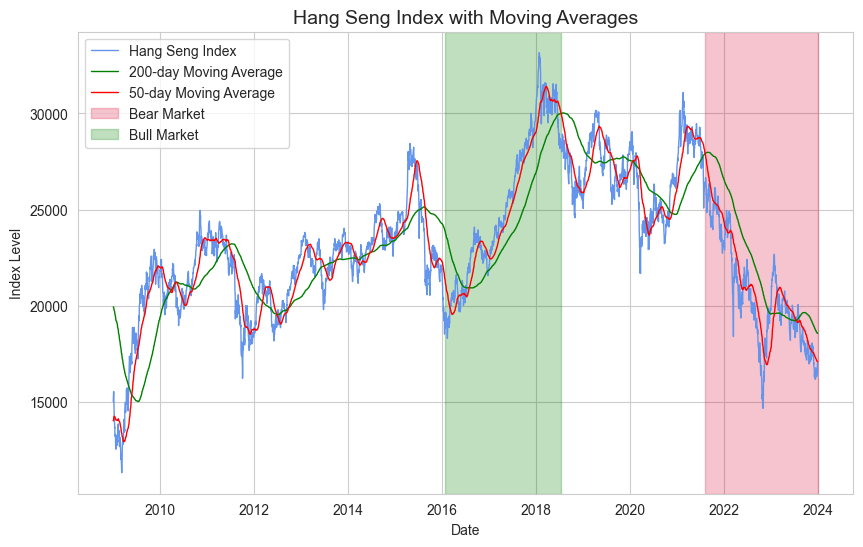

In [5]:
# -----------------------------------------------------------
# HANG SENG INDEX: TIME SERIES PLOT WITH MOVING AVERAGES
# -----------------------------------------------------------

# Import the required libraries
import pandas as pd              # For working with data tables
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns            # For nicer plot styling

# -----------------------------------------------------------
# STEP 1: LOAD THE DATA
# -----------------------------------------------------------

# Read the CSV file into a DataFrame
# (Make sure the file is in the same folder as your script,
# or provide the full file path)
df = pd.read_csv('Hang_Seng_Index.csv')

# -----------------------------------------------------------
# STEP 2: PREPARE THE DATE COLUMN
# -----------------------------------------------------------

# Convert the "New_date" column into a proper datetime format
# This allows Python to treat it as time (not just text)
df['Date'] = pd.to_datetime(df['New_date'])

# -----------------------------------------------------------
# STEP 3: SET THE PLOT STYLE
# -----------------------------------------------------------

# Use a clean background style
sns.set_style('whitegrid')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# -----------------------------------------------------------
# STEP 4: PLOT THE DATA
# -----------------------------------------------------------

# Plot the Hang Seng Index (closing prices)
ax.plot(df['Date'], df['Closing'],
        color='cornflowerblue',
        linewidth=1,
        label='Hang Seng Index')

# Plot the 200-day moving average (long-term trend)
ax.plot(df['Date'], df['MA200'],
        color='green',
        linewidth=1,
        label='200-day Moving Average')

# Plot the 50-day moving average (short-term trend)
ax.plot(df['Date'], df['MA50'],
        color='red',
        linewidth=1,
        label='50-day Moving Average')

# -----------------------------------------------------------
# STEP 5: HIGHLIGHT BULL AND BEAR MARKETS
# -----------------------------------------------------------

# Bear market (shaded in red)
ax.axvspan(pd.Timestamp('2021-08-09'),
           pd.Timestamp('2023-12-31'),
           color='crimson',
           alpha=0.25,
           label='Bear Market')

# Bull market (shaded in green)
ax.axvspan(pd.Timestamp('2016-01-21'),
           pd.Timestamp('2018-07-13'),
           color='green',
           alpha=0.25,
           label='Bull Market')

# -----------------------------------------------------------
# STEP 6: ADD LABELS AND LEGEND
# -----------------------------------------------------------

# Add title and axis labels
ax.set_title('Hang Seng Index with Moving Averages', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Index Level')

# Show legend
ax.legend()

# -----------------------------------------------------------
# STEP 7: SAVE AND DISPLAY THE PLOT
# -----------------------------------------------------------

# Save the figure BEFORE showing it
plt.savefig('Figure-Hang_Seng_Index.png',
            bbox_inches='tight',
            dpi=600)

# Display the plot on screen
plt.show()